In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv("/content/yield_df.csv")

print(df.head())

   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  


In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
le_area = LabelEncoder()
le_item = LabelEncoder()

df['Area'] = le_area.fit_transform(df['Area'])
df['Item'] = le_item.fit_transform(df['Item'])

In [ ]:
X = df.drop("hg/ha_yield", axis=1)
y = df["hg/ha_yield"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9729251861572266


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np

# Load dataset
data = pd.read_csv("/content/yield_df.csv")

# Drop unnecessary column
data = data.drop(columns=['Unnamed: 0'])

# Convert categorical columns into numerical
data = pd.get_dummies(data, columns=['Area','Item'])

# Features and target
X = data.drop('hg/ha_yield', axis=1)
y = data['hg/ha_yield']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost model
model = XGBRegressor()

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

#r2
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

# RMSE (optional)
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

R2 Score: 0.9759294390678406
Mean Squared Error: 174599952.0
Root Mean Squared Error: 13213.627511020582


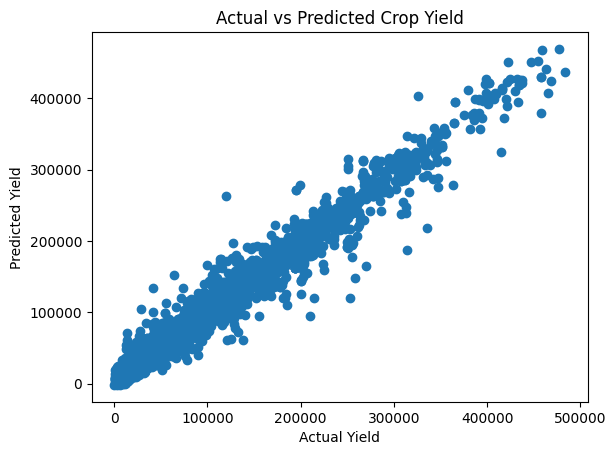

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")
plt.show()

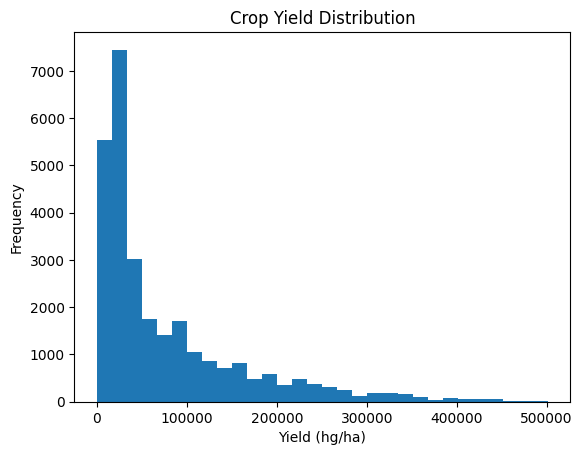

In [ ]:
import matplotlib.pyplot as plt

plt.hist(data['hg/ha_yield'], bins=30)
plt.title("Crop Yield Distribution")
plt.xlabel("Yield (hg/ha)")
plt.ylabel("Frequency")
plt.show()

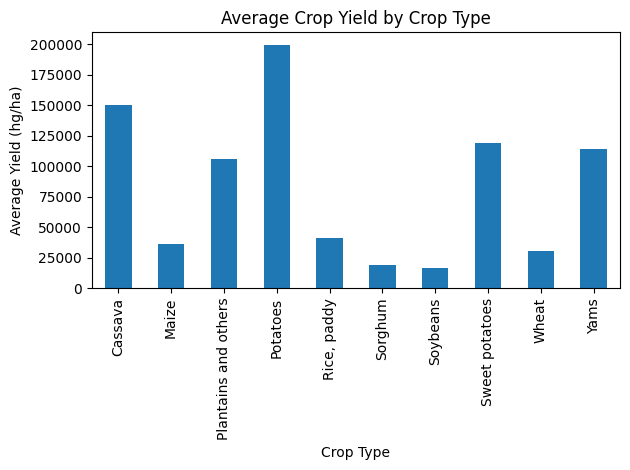

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Identify the one-hot encoded 'Item_' columns
item_cols = [col for col in data.columns if col.startswith('Item_')]

# Create a temporary DataFrame for plotting and analysis
temp_data = data.copy()
# Reconstruct the 'Item' category by finding which one-hot encoded column is '1'
temp_data['Item_Category'] = temp_data[item_cols].idxmax(axis=1).str.replace('Item_', '')

# Average yield per crop using the reconstructed item category
crop_yield = temp_data.groupby('Item_Category')['hg/ha_yield'].mean()

# Bar graph
crop_yield.plot(kind='bar')

plt.title("Average Crop Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (hg/ha)")
plt.xticks(rotation=90)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

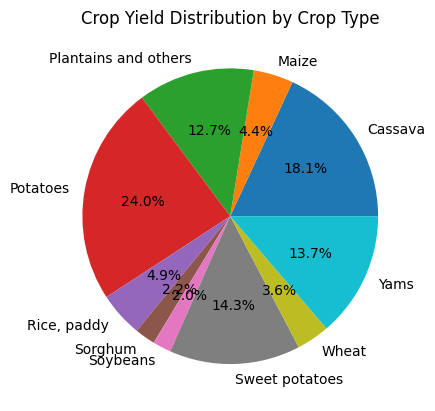

In [ ]:
# Pie chart
crop_yield.plot(kind='pie', autopct='%1.1f%%')

plt.title("Crop Yield Distribution by Crop Type")
plt.ylabel("")
plt.show()

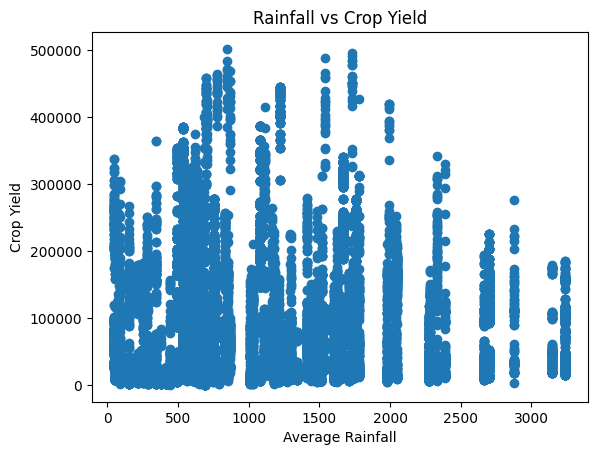

In [ ]:
plt.scatter(data['average_rain_fall_mm_per_year'], data['hg/ha_yield'])
plt.xlabel("Average Rainfall")
plt.ylabel("Crop Yield")
plt.title("Rainfall vs Crop Yield")
plt.show()

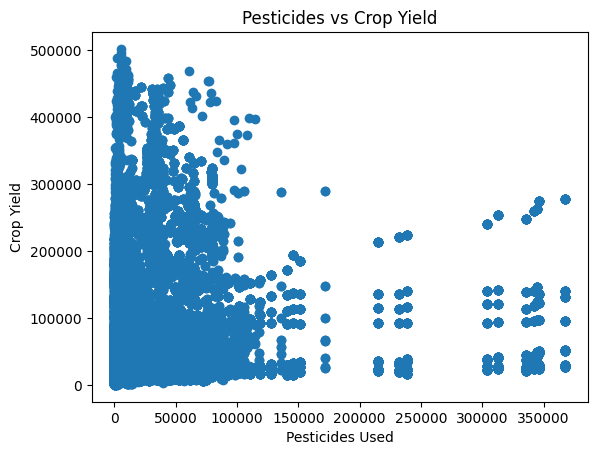

In [ ]:
plt.scatter(data['pesticides_tonnes'], data['hg/ha_yield'])
plt.xlabel("Pesticides Used")
plt.ylabel("Crop Yield")
plt.title("Pesticides vs Crop Yield")
plt.show()

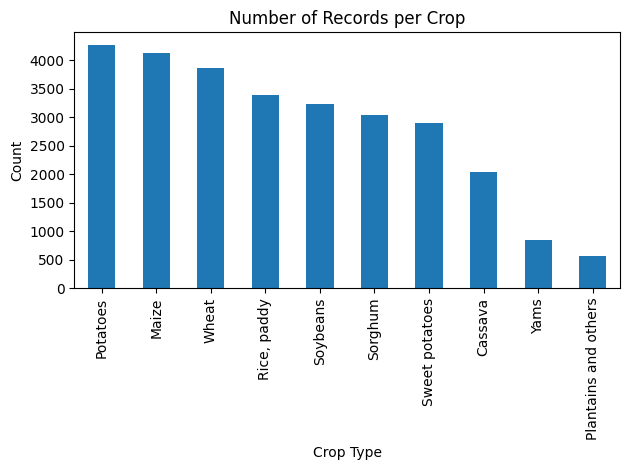

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Identify the one-hot encoded 'Item_' columns
item_cols = [col for col in data.columns if col.startswith('Item_')]

# Create a temporary DataFrame for plotting
temp_data_for_plot = data.copy()
# Reconstruct the 'Item' category by finding which one-hot encoded column is '1'
temp_data_for_plot['Item_Category'] = temp_data_for_plot[item_cols].idxmax(axis=1).str.replace('Item_', '')

# Now plot the value counts of the reconstructed 'Item_Category'
temp_data_for_plot['Item_Category'].value_counts().plot(kind='bar')
plt.title("Number of Records per Crop")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()